In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("bank-full.csv", sep=";")
print("Columns in the dashboard dataset:")
print(df.columns.tolist())
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Columns in the dashboard dataset:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Dataset loaded successfully!
Dataset shape: (45211, 17)


In [6]:
# ==============================
# KPI CALCULATIONS
# ==============================

total_customers = len(df)

successful_conversions = (df["y"] == "yes").sum()

conversion_rate = (
    successful_conversions / total_customers
) * 100

dropoff_rate = 100 - conversion_rate

print("Total Customers:", total_customers)
print("Successful Conversions:", successful_conversions)
print("Conversion Rate:", round(conversion_rate, 2), "%")
print("Drop-off Rate:", round(dropoff_rate, 2), "%")

Total Customers: 45211
Successful Conversions: 5289
Conversion Rate: 11.7 %
Drop-off Rate: 88.3 %


In [7]:
from IPython.display import display, HTML

display(HTML(f"""
<div style="display:flex; gap:20px; margin:20px 0;">

    <div style="background:#E8F4FD; padding:20px; width:220px;
                text-align:center; border-radius:10px;">
        <h3>Total Customers</h3>
        <h1>{total_customers:,}</h1>
    </div>

    <div style="background:#E8F8EE; padding:20px; width:220px;
                text-align:center; border-radius:10px;">
        <h3>Successful Conversions</h3>
        <h1>{successful_conversions:,}</h1>
    </div>

    <div style="background:#FFF4E5; padding:20px; width:220px;
                text-align:center; border-radius:10px;">
        <h3>Conversion Rate</h3>
        <h1>{conversion_rate:.2f}%</h1>
    </div>

    <div style="background:#FDECEC; padding:20px; width:220px;
                text-align:center; border-radius:10px;">
        <h3>Drop-off Rate</h3>
        <h1>{dropoff_rate:.2f}%</h1>
    </div>

</div>
"""))

In [8]:
# Conversion analysis by contact method

contact_analysis = df.groupby("contact")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

contact_analysis["conversion_rate"] = (
    contact_analysis["successful_conversions"]
    / contact_analysis["total_customers"]
) * 100

print("Conversion analysis by contact method:")
print(contact_analysis.round(2))

Conversion analysis by contact method:
           total_customers  successful_conversions  conversion_rate
contact                                                            
cellular             29285                    4369            14.92
telephone             2906                     390            13.42
unknown              13020                     530             4.07


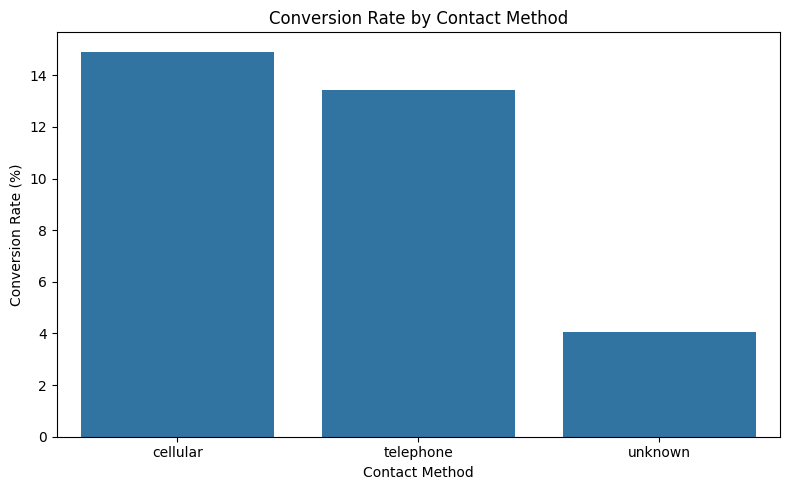

In [9]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contact_analysis.index,
    y=contact_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

In [10]:
# Conversion analysis by campaign contact group

df["campaign_group"] = pd.cut(
    df["campaign"],
    bins=[0, 1, 3, 5, 10, float("inf")],
    labels=[
        "1 contact",
        "2-3 contacts",
        "4-5 contacts",
        "6-10 contacts",
        "11+ contacts"
    ]
)

campaign_group_analysis = df.groupby(
    "campaign_group", observed=False
)["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

campaign_group_analysis["conversion_rate"] = (
    campaign_group_analysis["successful_conversions"]
    / campaign_group_analysis["total_customers"]
) * 100

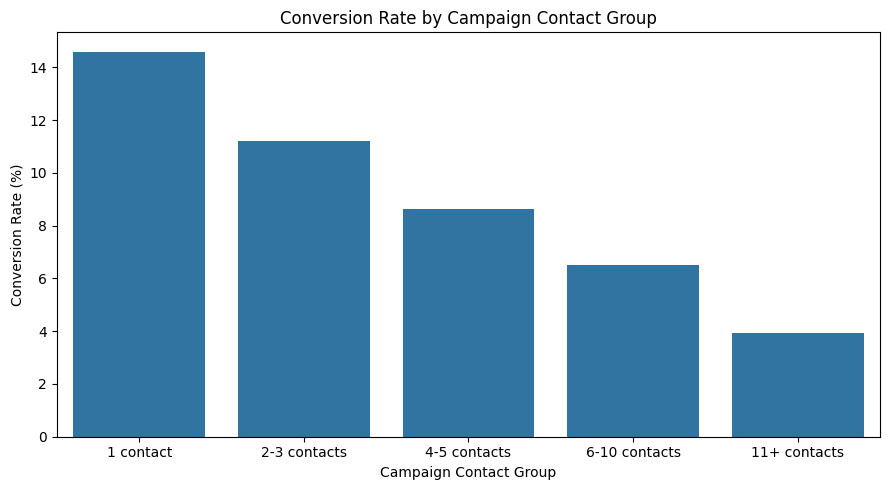

In [11]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=campaign_group_analysis.index,
    y=campaign_group_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Campaign Contact Group")
plt.xlabel("Campaign Contact Group")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

In [12]:
# Conversion analysis by month

month_analysis = df.groupby("month")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

month_analysis["conversion_rate"] = (
    month_analysis["successful_conversions"]
    / month_analysis["total_customers"]
) * 100

# Arrange months in calendar order
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

month_analysis = month_analysis.reindex(month_order)

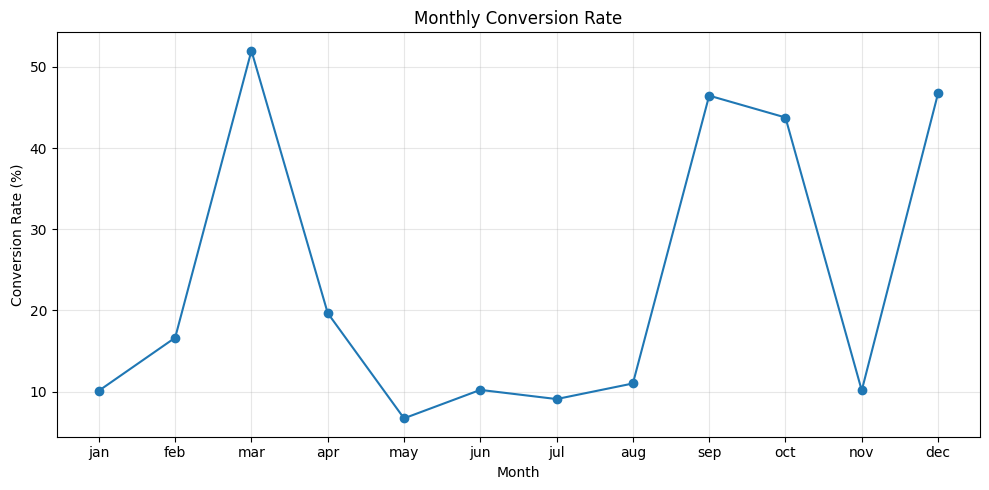

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    month_analysis.index,
    month_analysis["conversion_rate"],
    marker="o"
)

plt.title("Monthly Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Create age groups

df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, float("inf")],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

age_analysis = df.groupby(
    "age_group", observed=False
)["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

age_analysis["conversion_rate"] = (
    age_analysis["successful_conversions"]
    / age_analysis["total_customers"]
) * 100

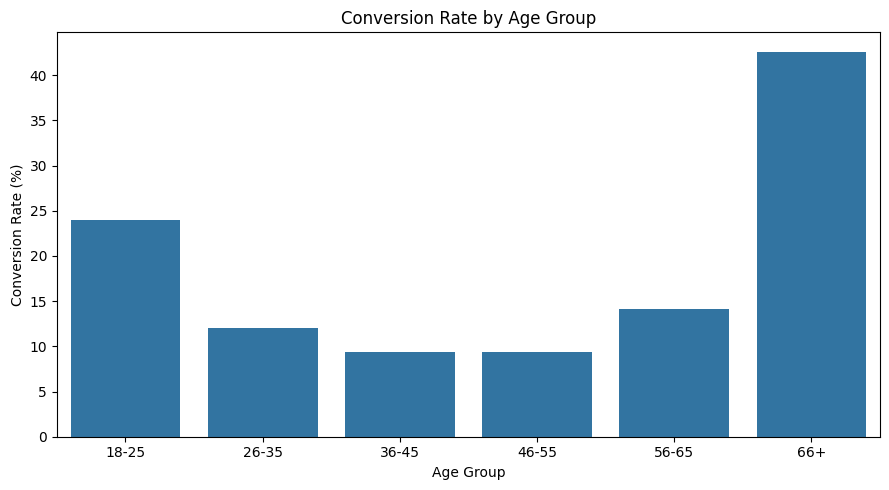

In [15]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_analysis.index,
    y=age_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

In [16]:
# Conversion analysis by job category

job_analysis = df.groupby("job")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

job_analysis["conversion_rate"] = (
    job_analysis["successful_conversions"]
    / job_analysis["total_customers"]
) * 100

# Sort for easier visualization
job_analysis = job_analysis.sort_values("conversion_rate", ascending=True)

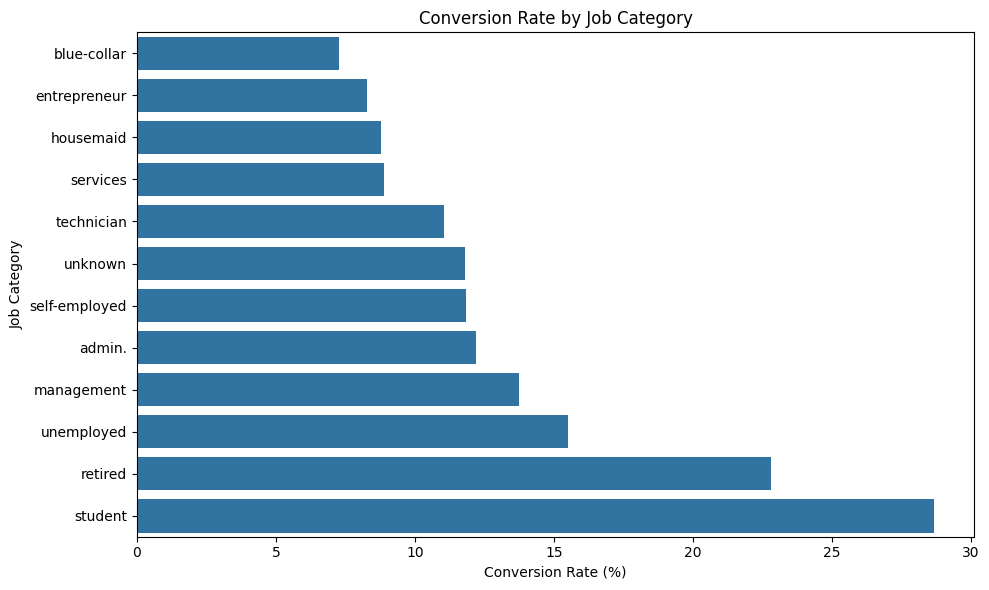

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    y=job_analysis.index,
    x=job_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Job Category")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Job Category")

plt.tight_layout()
plt.show()

In [18]:
# Conversion analysis by previous campaign outcome

previous_analysis = df.groupby("poutcome")["y"].agg(
    total_customers="count",
    successful_conversions=lambda x: (x == "yes").sum()
)

previous_analysis["conversion_rate"] = (
    previous_analysis["successful_conversions"]
    / previous_analysis["total_customers"]
) * 100

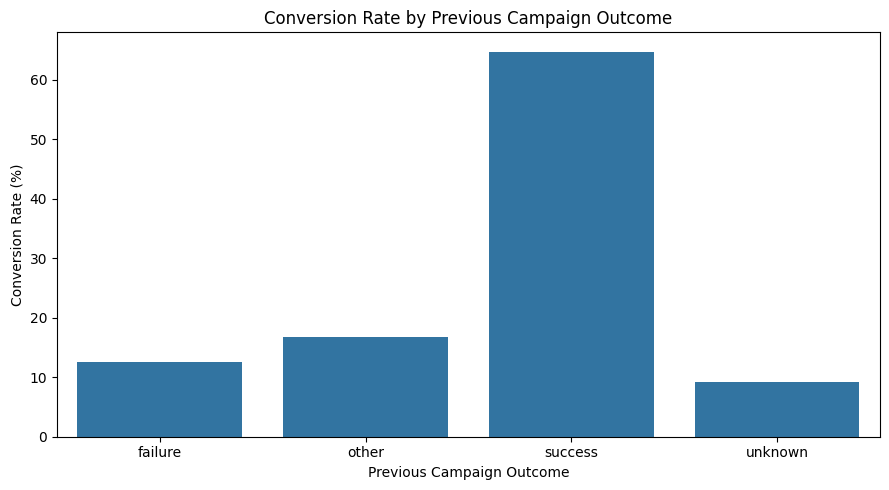

In [19]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=previous_analysis.index,
    y=previous_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

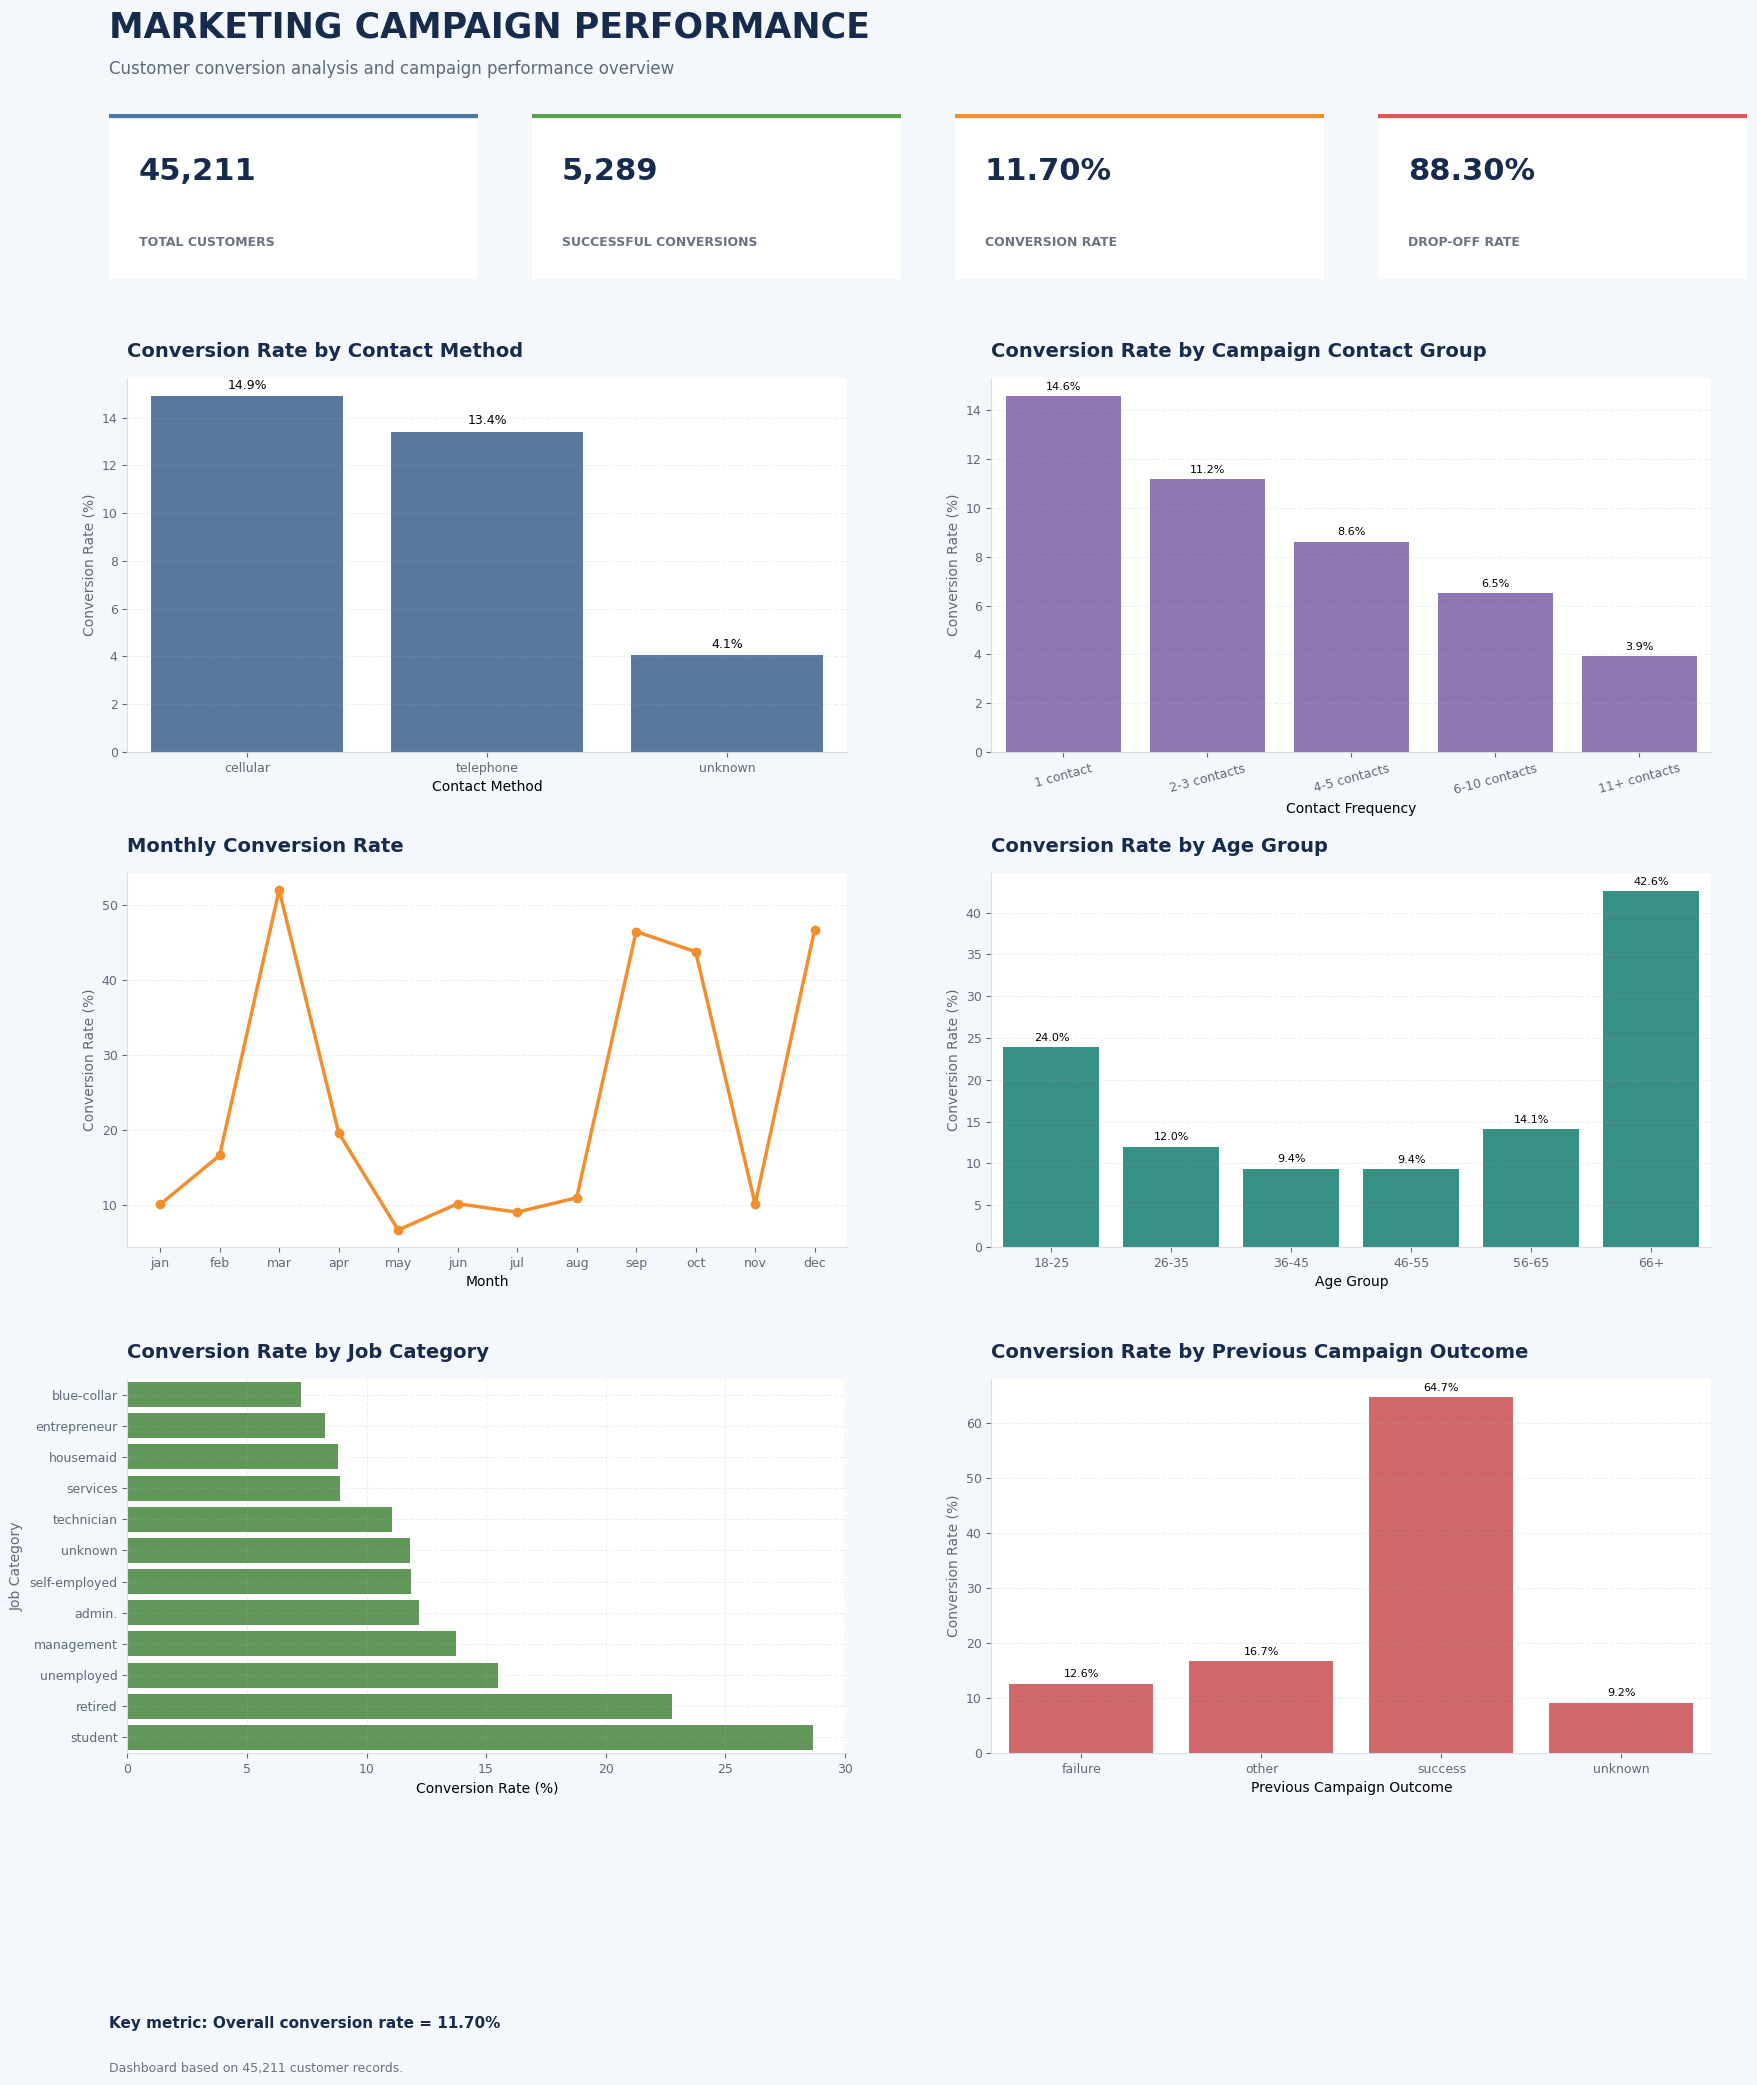

In [24]:
# ==========================================
# PROFESSIONAL + COLORFUL MARKETING DASHBOARD
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Dashboard colors
bg_color = "#F4F7FB"
navy = "#172B4D"
blue = "#4C78A8"
green = "#59A14F"
orange = "#F28E2B"
purple = "#8E6BBE"
pink = "#E15759"
teal = "#2A9D8F"

# Create dashboard
fig = plt.figure(figsize=(18, 22), facecolor=bg_color)

# ------------------------------------------
# TITLE
# ------------------------------------------

fig.text(
    0.05, 0.975,
    "MARKETING CAMPAIGN PERFORMANCE",
    fontsize=25,
    fontweight="bold",
    color=navy
)

fig.text(
    0.05, 0.958,
    "Customer conversion analysis and campaign performance overview",
    fontsize=12,
    color="#5F6B7A"
)


# ------------------------------------------
# KPI CARDS
# ------------------------------------------

kpi_data = [
    ("TOTAL CUSTOMERS", f"{total_customers:,}", blue),
    ("SUCCESSFUL CONVERSIONS", f"{successful_conversions:,}", green),
    ("CONVERSION RATE", f"{conversion_rate:.2f}%", orange),
    ("DROP-OFF RATE", f"{dropoff_rate:.2f}%", pink)
]

for i, (title, value, color) in enumerate(kpi_data):

    ax = fig.add_axes([
        0.05 + i * 0.235,
        0.865,
        0.205,
        0.075
    ])

    ax.set_facecolor("white")

    # Colored top line
    ax.plot(
        [0, 1],
        [1, 1],
        transform=ax.transAxes,
        color=color,
        linewidth=6,
        solid_capstyle="round"
    )

    ax.text(
        0.08, 0.60,
        value,
        transform=ax.transAxes,
        fontsize=22,
        fontweight="bold",
        color=navy
    )

    ax.text(
        0.08, 0.20,
        title,
        transform=ax.transAxes,
        fontsize=9,
        fontweight="bold",
        color="#6B7280"
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


# ------------------------------------------
# CHART PANEL FUNCTION
# ------------------------------------------

def style_chart(ax, title, color):

    ax.set_facecolor("white")

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        color=navy,
        loc="left",
        pad=15
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.20
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#D9DEE7")
    ax.spines["bottom"].set_color("#D9DEE7")

    ax.tick_params(
        colors="#5F6B7A",
        labelsize=9
    )

    ax.set_ylabel(
        "Conversion Rate (%)",
        color="#5F6B7A"
    )


# ------------------------------------------
# CHART 1 - CONTACT METHOD
# ------------------------------------------

ax1 = fig.add_axes([0.06, 0.65, 0.40, 0.17])

sns.barplot(
    x=contact_analysis.index,
    y=contact_analysis["conversion_rate"],
    color=blue,
    ax=ax1
)

style_chart(
    ax1,
    "Conversion Rate by Contact Method",
    blue
)

ax1.set_xlabel("Contact Method")

for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )


# ------------------------------------------
# CHART 2 - CAMPAIGN CONTACT GROUP
# ------------------------------------------

ax2 = fig.add_axes([0.54, 0.65, 0.40, 0.17])

sns.barplot(
    x=campaign_group_analysis.index,
    y=campaign_group_analysis["conversion_rate"],
    color=purple,
    ax=ax2
)

style_chart(
    ax2,
    "Conversion Rate by Campaign Contact Group",
    purple
)

ax2.set_xlabel("Contact Frequency")
ax2.tick_params(axis="x", rotation=15)

for container in ax2.containers:
    ax2.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )


# ------------------------------------------
# CHART 3 - MONTHLY CONVERSION
# ------------------------------------------

ax3 = fig.add_axes([0.06, 0.425, 0.40, 0.17])

ax3.plot(
    month_analysis.index,
    month_analysis["conversion_rate"],
    marker="o",
    linewidth=2.5,
    color=orange
)

style_chart(
    ax3,
    "Monthly Conversion Rate",
    orange
)

ax3.set_xlabel("Month")

ax3.grid(
    axis="y",
    linestyle="--",
    alpha=0.20
)


# ------------------------------------------
# CHART 4 - AGE GROUP
# ------------------------------------------

ax4 = fig.add_axes([0.54, 0.425, 0.40, 0.17])

sns.barplot(
    x=age_analysis.index,
    y=age_analysis["conversion_rate"],
    color=teal,
    ax=ax4
)

style_chart(
    ax4,
    "Conversion Rate by Age Group",
    teal
)

ax4.set_xlabel("Age Group")

for container in ax4.containers:
    ax4.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )


# ------------------------------------------
# CHART 5 - JOB CATEGORY
# ------------------------------------------

ax5 = fig.add_axes([0.06, 0.195, 0.40, 0.17])

sns.barplot(
    y=job_analysis.index,
    x=job_analysis["conversion_rate"],
    color=green,
    ax=ax5
)

style_chart(
    ax5,
    "Conversion Rate by Job Category",
    green
)

ax5.set_xlabel("Conversion Rate (%)")
ax5.set_ylabel("Job Category")

ax5.grid(
    axis="x",
    linestyle="--",
    alpha=0.20
)


# ------------------------------------------
# CHART 6 - PREVIOUS CAMPAIGN OUTCOME
# ------------------------------------------

ax6 = fig.add_axes([0.54, 0.195, 0.40, 0.17])

sns.barplot(
    x=previous_analysis.index,
    y=previous_analysis["conversion_rate"],
    color=pink,
    ax=ax6
)

style_chart(
    ax6,
    "Conversion Rate by Previous Campaign Outcome",
    pink
)

ax6.set_xlabel("Previous Campaign Outcome")

for container in ax6.containers:
    ax6.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )


# ------------------------------------------
# FOOTER
# ------------------------------------------

fig.text(
    0.05, 0.07,
    "Key metric: Overall conversion rate = 11.70%",
    fontsize=11,
    fontweight="bold",
    color=navy
)

fig.text(
    0.05, 0.05,
    "Dashboard based on 45,211 customer records.",
    fontsize=9,
    color="#6B7280"
)

plt.show()

## Key Insights

- The campaign contacted **45,211 customers** and achieved **5,289 successful conversions**, resulting in an overall conversion rate of **11.70%**.
- **Cellular** contact had the highest observed conversion rate among the contact methods at **14.92%**.
- Customers with a previous campaign outcome of **success** showed an observed conversion rate of **64.73%**.
- Conversion rates generally decreased as the number of campaign contacts increased, from **14.60% for one contact** to **3.93% for 11+ contacts**.
- Conversion rates varied considerably across months and customer groups, indicating differences in campaign response across time and customer characteristics.